In [96]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [97]:

df = pd.read_csv('shopping-data.csv')
# df = pd.read_csv('customer_shopping_data.csv')
df.head()
# df.info()
# df.isnull().sum()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [98]:
# data = df[['age', 'quantity', 'price']].values
data = df.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']].values
# data.info()
# data.head()


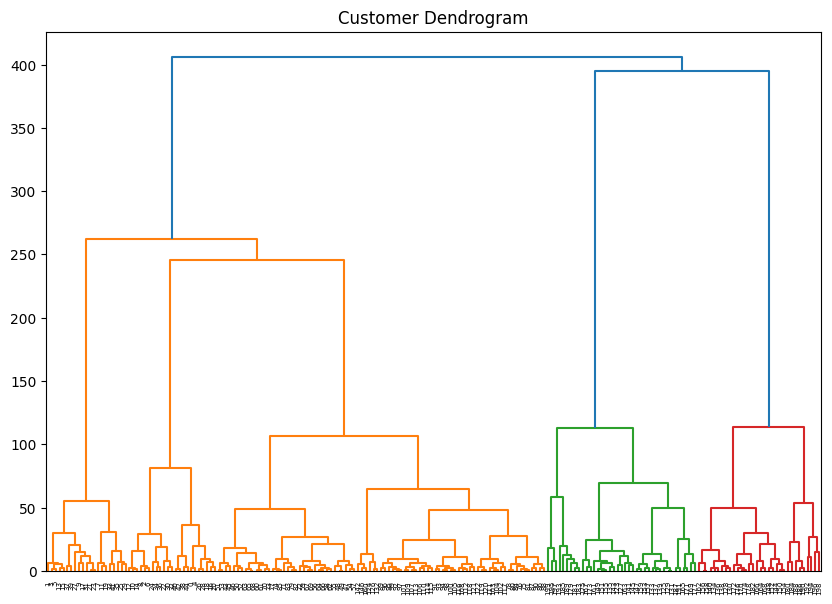

In [109]:
plt.figure(figsize=(10,7))
plt.title('Customer Dendrogram')
dend = dendrogram(linkage(data, method='ward'))
# plt.grid()

In [100]:
cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = cluster.fit_predict(data)
# labels

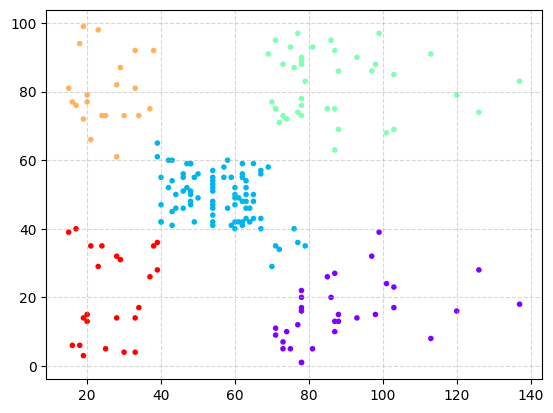

In [108]:
plt.scatter(data[:, 0], data[:, 1], c=cluster.labels_, cmap='rainbow', marker='.')
plt.grid(linestyle='--', alpha=.5)

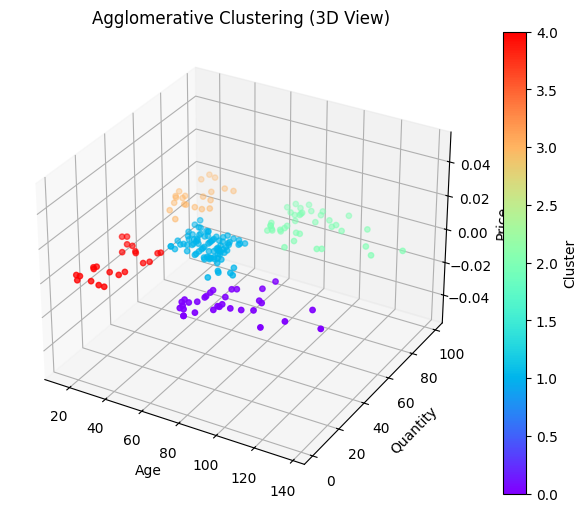

In [103]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    data[:, 0],          # Age
    data[:, 1],          # Quantity
    # data[:, 2],          # Price
    c=cluster.labels_,   # Cluster labels
    cmap='rainbow',
    s=60,
    marker='.'
)

ax.set_xlabel("Age")
ax.set_ylabel("Quantity")
ax.set_zlabel("Price")

plt.title("Agglomerative Clustering (3D View)")
fig.colorbar(scatter, label="Cluster")
plt.show()